<a href="https://colab.research.google.com/github/hariharan-vs/24ADI003---24BAD030/blob/main/ML_24BAD030_Lab_exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)

Missing Values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Basic Statistics:

              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000 

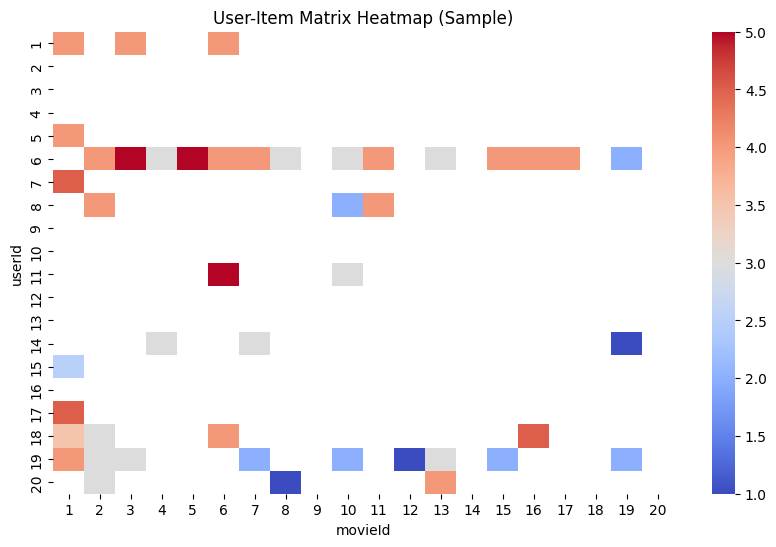

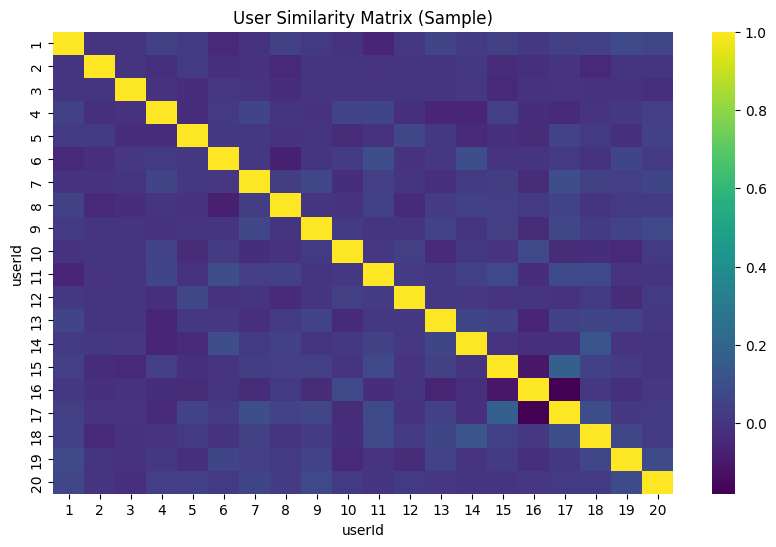

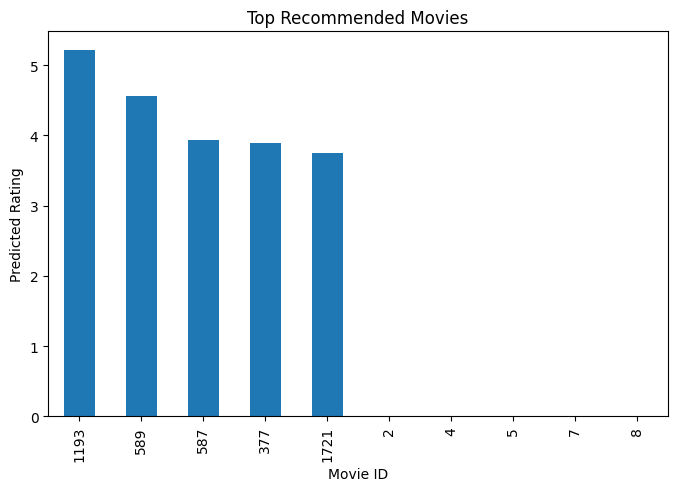

In [8]:
print("Hariharan V S - 24BAD030")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

print("\nMissing Values:\n", ratings.isnull().sum())
print("\nDataset Info:\n")
print(ratings.info())

print("\nBasic Statistics:\n")
print(ratings.describe())

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

user_means = user_item_matrix.mean(axis=1)
user_item_centered = user_item_matrix.sub(user_means, axis=0)

user_item_filled = user_item_centered.fillna(0);

user_similarity = cosine_similarity(user_item_filled);

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_filled.index,
                                  columns=user_item_filled.index);

def get_similar_users(user_id, n=5):
    sim_users = user_similarity_df[user_id].sort_values(ascending=False);
    sim_users = sim_users.drop(user_id);
    return sim_users.head(n);

def predict_ratings(user_id, n_neighbors=5):
    similar_users = get_similar_users(user_id, n_neighbors);

    sim_users_ids = similar_users.index;
    sim_scores = similar_users.values;

    sim_users_ratings = user_item_centered.loc[sim_users_ids];

    weighted_sum = np.dot(sim_scores, sim_users_ratings);
    sim_sum = np.sum(np.abs(sim_scores));

    if sim_sum == 0:
        return pd.Series(0, index=user_item_matrix.columns);

    pred_centered = weighted_sum / sim_sum;
    pred_final = pred_centered + user_means[user_id];

    return pd.Series(pred_final, index=user_item_matrix.columns);

def recommend_movies(user_id, n=10):
    predictions = predict_ratings(user_id);

    watched = user_item_matrix.loc[user_id].dropna().index;
    predictions = predictions.drop(watched);

    top_movies = predictions.sort_values(ascending=False).head(n);
    return top_movies;

user_id = 1;
recommended = recommend_movies(user_id, 10);

recommended_movies = movies[movies['movieId'].isin(recommended.index)];

print("\nTop Recommendations for User", user_id);
print(recommended_movies[['movieId', 'title']]);

test_data = ratings.sample(frac=0.2, random_state=42);

y_true = [];
y_pred = [];

for _, row in test_data.iterrows():
    user = row['userId'];
    movie = row['movieId'];
    actual = row['rating'];

    if user in user_item_matrix.index:
        preds = predict_ratings(user);

        if movie in preds.index:
            pred = preds[movie];

            if not np.isnan(pred):
                y_true.append(actual);
                y_pred.append(pred);

y_true = np.array(y_true);
y_pred = np.array(y_pred);

rmse = np.sqrt(mean_squared_error(y_true, y_pred));
mae = mean_absolute_error(y_true, y_pred);

print("\nEvaluation Metrics");
print("RMSE:", rmse);
print("MAE:", mae);

total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1];
non_null = user_item_matrix.count().sum();

sparsity = 1 - (non_null / total_cells);

print("\nMatrix Sparsity:", sparsity);

print("\nTop Similar Users for User", user_id);
print(get_similar_users(user_id, 5));

for uid in [1, 5, 10]:
    print(f"\nTop Recommendations for User {uid}");
    recs = recommend_movies(uid, 5);
    rec_movies = movies[movies['movieId'].isin(recs.index)];
    print(rec_movies[['movieId', 'title']]);

plt.figure(figsize=(10,6));
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='coolwarm');
plt.title("User-Item Matrix Heatmap (Sample)");
plt.show();

plt.figure(figsize=(10,6));
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis');
plt.title("User Similarity Matrix (Sample)");
plt.show();

plt.figure(figsize=(8,5));
recommended.head(10).plot(kind='bar');
plt.title("Top Recommended Movies");
plt.xlabel("Movie ID");
plt.ylabel("Predicted Rating");
plt.show();

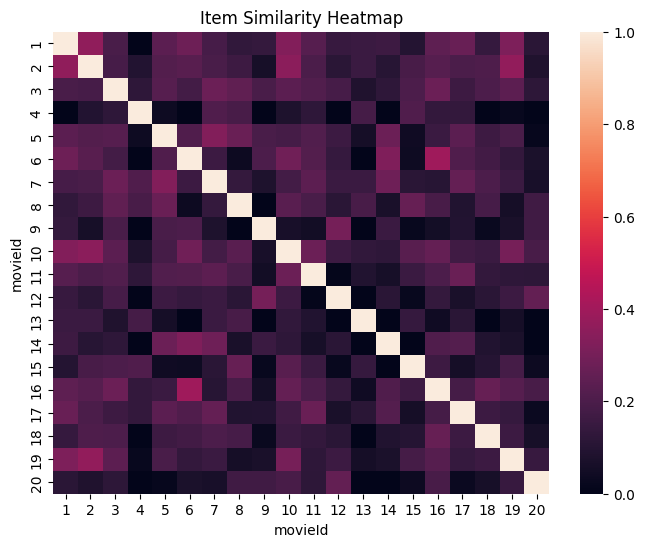

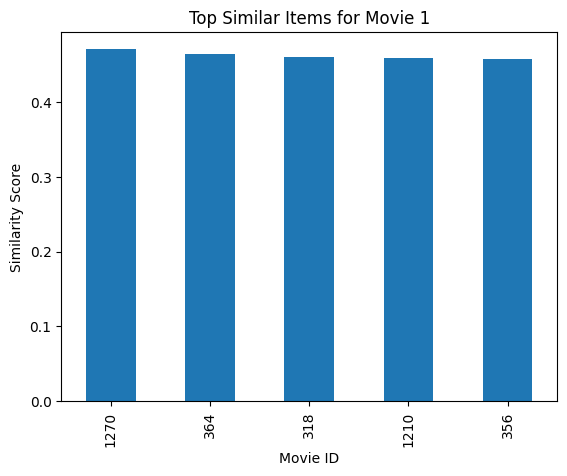

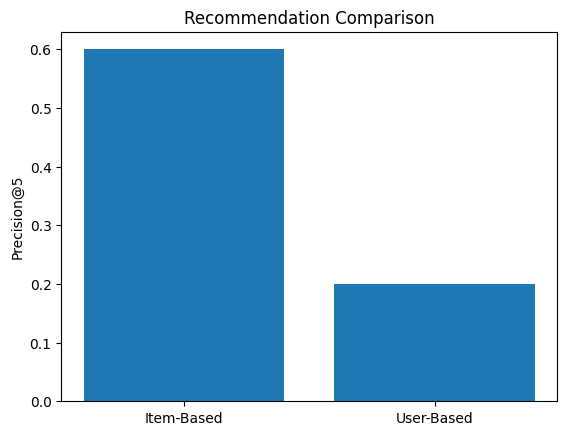

Recommended Movies (Item-Based): [2115, 1580, 2987, 1527, 1214]
Recommended Movies (User-Based): [2028, 2571, 1242, 2115, 356]
RMSE (Decision Tree): 1.2816742617099364
Precision@5 (Item-Based): 0.6
Precision@5 (User-Based): 0.2

========== ANALYSIS ==========

1. Accuracy:
- Item-based filtering gives stable recommendations.
- User-based filtering depends on user similarity.

2. Popular vs Niche:
- Popular items have more interactions → better similarity.
- Niche items suffer due to sparse data.

3. Scalability:
- Item-based filtering is scalable.
- Suitable for large number of users.

========== END ==========


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_data.pivot_table(index='movieId', columns='userId', values='rating').fillna(0)
test_matrix = test_data.pivot_table(index='movieId', columns='userId', values='rating').fillna(0)

item_similarity = cosine_similarity(train_matrix)
item_similarity_df = pd.DataFrame(item_similarity, index=train_matrix.index, columns=train_matrix.index)

def get_similar_items(movie_id, top_n=5):
    if movie_id not in item_similarity_df.index:
        return []
    similar_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return similar_scores.iloc[1:top_n+1]

def recommend_movies(user_id, top_n=5):
    if user_id not in train_matrix.columns:
        return []
    user_ratings = train_matrix[user_id]
    watched_movies = user_ratings[user_ratings > 0].index
    scores = {}
    for movie in watched_movies:
        similar_items = item_similarity_df[movie]
        for sim_movie, score in similar_items.items():
            if sim_movie not in watched_movies:
                scores[sim_movie] = scores.get(sim_movie, 0) + score
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in recommended[:top_n]]

user_similarity = cosine_similarity(train_matrix.T)
user_similarity_df = pd.DataFrame(user_similarity, index=train_matrix.columns, columns=train_matrix.columns)

def user_based_recommend(user_id, top_n=5):
    if user_id not in user_similarity_df.index:
        return []
    sim_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    scores = {}
    for sim_user in sim_users.index:
        sim_score = sim_users[sim_user]
        user_ratings = train_matrix[sim_user]
        for movie, rating in user_ratings.items():
            if rating > 0:
                scores[movie] = scores.get(movie, 0) + sim_score * rating
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in recommended[:top_n]]

def precision_at_k(user_id, k=5):
    recommended = recommend_movies(user_id, k)
    if user_id not in test_matrix.columns:
        return 0
    relevant = test_matrix[user_id]
    relevant_items = relevant[relevant > 3].index.tolist()
    if len(relevant_items) == 0:
        return 0
    hits = len(set(recommended) & set(relevant_items))
    return hits / k

def precision_at_k_user(user_id, k=5):
    recommended = user_based_recommend(user_id, k)
    if user_id not in test_matrix.columns:
        return 0
    relevant = test_matrix[user_id]
    relevant_items = relevant[relevant > 3].index.tolist()
    if len(relevant_items) == 0:
        return 0
    hits = len(set(recommended) & set(relevant_items))
    return hits / k

model = DecisionTreeRegressor()
model.fit(train_data[['userId', 'movieId']], train_data['rating'])

y_true = test_data['rating']
y_pred_tree = model.predict(test_data[['userId', 'movieId']])
rmse_tree = np.sqrt(mean_squared_error(y_true, y_pred_tree))

user_id = 1
item_recommendations = recommend_movies(user_id)
user_recommendations = user_based_recommend(user_id)

precision_item = precision_at_k(user_id, 5)
precision_user = precision_at_k_user(user_id, 5)

plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

similar_items = get_similar_items(1, 5)

plt.figure()
similar_items.plot(kind='bar')
plt.title("Top Similar Items for Movie 1")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()

labels = ['Item-Based', 'User-Based']
values = [precision_item, precision_user]

plt.figure()
plt.bar(labels, values)
plt.title("Recommendation Comparison")
plt.ylabel("Precision@5")
plt.show()

print("Recommended Movies (Item-Based):", item_recommendations)
print("Recommended Movies (User-Based):", user_recommendations)
print("RMSE (Decision Tree):", rmse_tree)
print("Precision@5 (Item-Based):", precision_item)
print("Precision@5 (User-Based):", precision_user)

print("\n========== ANALYSIS ==========")

print("\n1. Accuracy:")
print("- Item-based filtering gives stable recommendations.")
print("- User-based filtering depends on user similarity.")

print("\n2. Popular vs Niche:")
print("- Popular items have more interactions → better similarity.")
print("- Niche items suffer due to sparse data.")

print("\n3. Scalability:")
print("- Item-based filtering is scalable.")
print("- Suitable for large number of users.")

print("\n========== END ==========")